In [5]:
import torch
from diffusion.approaches.matching.prob_paths import (
    GaussianCondProbPath,
    LinearAlpha,
    LinearBeta,
)
from diffusion.architectures.backbones.res_unet import ResUnet
from diffusion.approaches.matching.flow_generator import FlowGenerator, ScoreGenerator
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg
from diffusion.sampleables.whar_sampleable import WHARSampleable, TrainValTest
from diffusion.architectures.classifiers.wisdm_classifier import WISDMClassifier
from diffusion.evaluation.evaluate import (
    visualize_tsne_per_class,
    compute_samples,
    plot_metrics_per_class,
    visualize_samples_per_class,
    compute_features,
    evaluate_features,
)
from diffusion.sampleables.whar_sampleable import stft_transform_combine

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_dataset_cfg(WHARDatasetID.WISDM)
transform = lambda x: stft_transform_combine(x, n_fft=64, hop_length=2)  # type: ignore
scv_group_index = 0

2025-10-23 16:58:14,634 - whar-datasets - INFO - Running DownloadingStep
2025-10-23 16:58:14,634 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-23 16:58:14,635 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:14,635 - whar-datasets - INFO - Running ParsingStep
2025-10-23 16:58:14,636 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-23 16:58:14,637 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:14,637 - whar-datasets - INFO - Running WindowingStep
2025-10-23 16:58:14,637 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-23 16:58:14,639 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:14,639 - whar-datasets - INFO - Loading windowing
2025-10-23 16:58:14,650 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-23 16:58:14,650 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-23 16:58:14,654 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-23 16:58:14,655 - whar-datasets - INFO - R

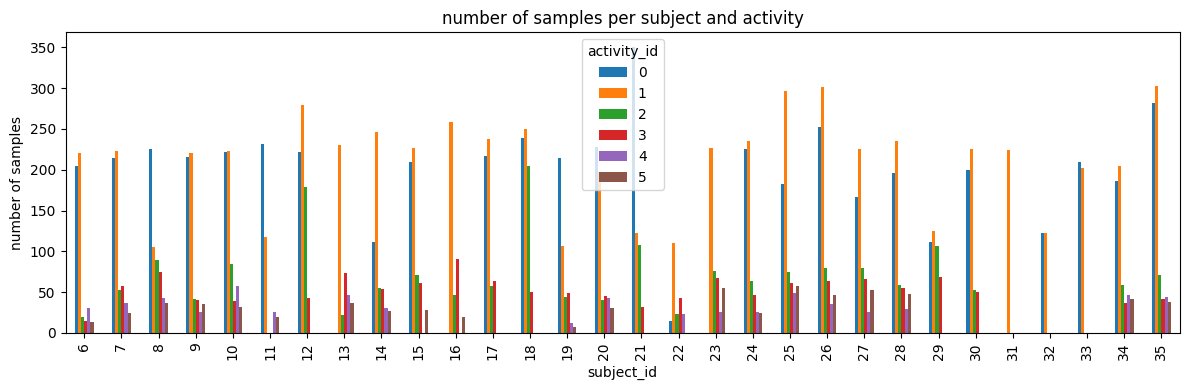

2025-10-23 16:58:17,752 - whar-datasets - INFO - Running DownloadingStep
2025-10-23 16:58:17,752 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-23 16:58:17,753 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:17,753 - whar-datasets - INFO - Running ParsingStep
2025-10-23 16:58:17,753 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-23 16:58:17,754 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:17,754 - whar-datasets - INFO - Running WindowingStep
2025-10-23 16:58:17,755 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-23 16:58:17,755 - whar-datasets - INFO - Hash is up to date
2025-10-23 16:58:17,756 - whar-datasets - INFO - Loading windowing
2025-10-23 16:58:17,783 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-23 16:58:17,786 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-23 16:58:17,791 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-23 16:58:17,793 - whar-datasets - INFO - R

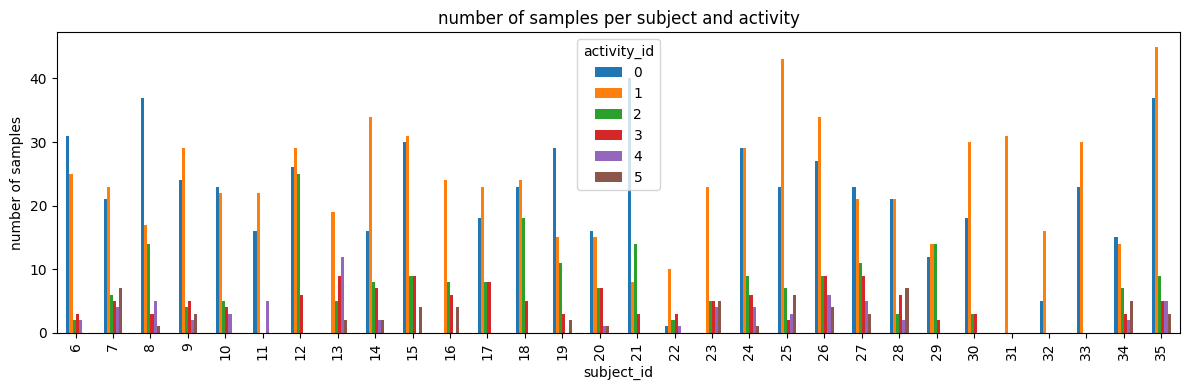

(6, 33, 51)
6


In [6]:
sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.TRAIN,
    transform=transform,
)

val_sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.VAL,
    transform=transform,
)

print(sampeable.shape)
print(sampeable.num_classes)

In [12]:
path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=sampeable.shape[0],
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)
backbone.load_state_dict(torch.load("./models/backbone_flow_wisdm.pt"))

classifier = WISDMClassifier(
    in_c=sampeable.shape[0], num_classes=sampeable.num_classes, size=6144
).to(device)
classifier.load_state_dict(torch.load("./models/classifier.pt"))

<All keys matched successfully>

In [9]:
num_timesteps = 10
samples_per_class = 200
guidance_scale = 2.0

flow_generator = FlowGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_flow, real_list_flow = compute_samples(
    generator=flow_generator,
    p_data=val_sampeable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

x1_list_flow_t, real_list_flow_t = compute_samples(
    generator=flow_generator,
    p_data=val_sampeable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

# visualize_samples_per_class(x1_list_flow, real_list_flow)

100%|██████████| 9/9 [00:02<00:00,  3.47it/s]


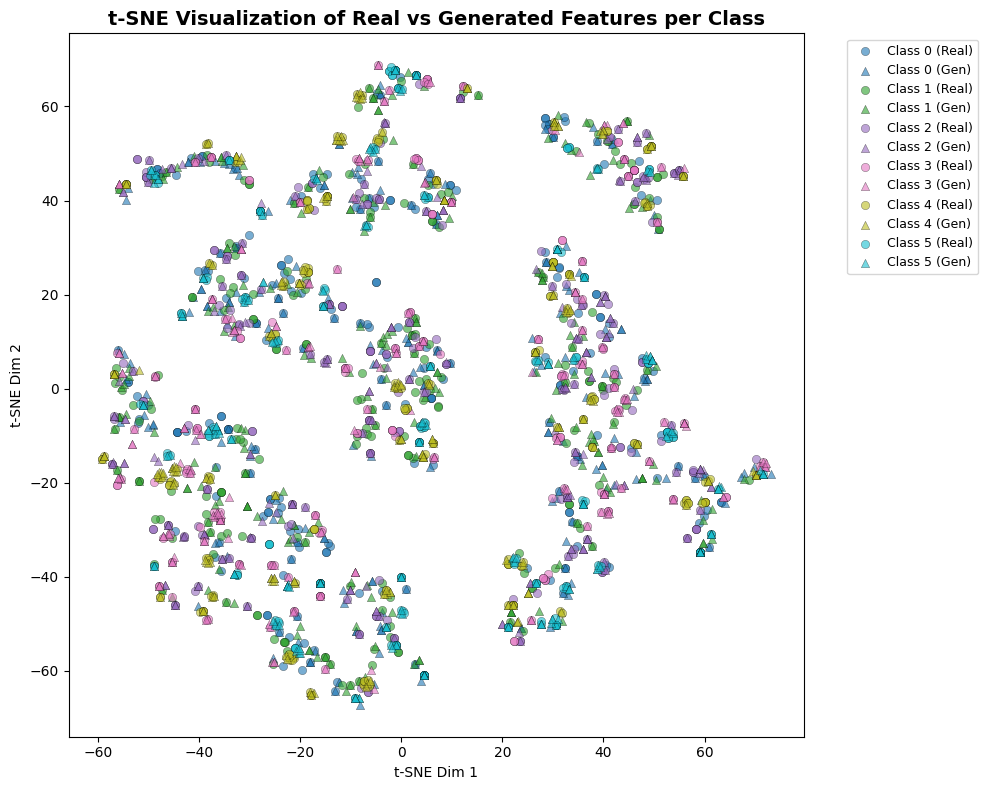

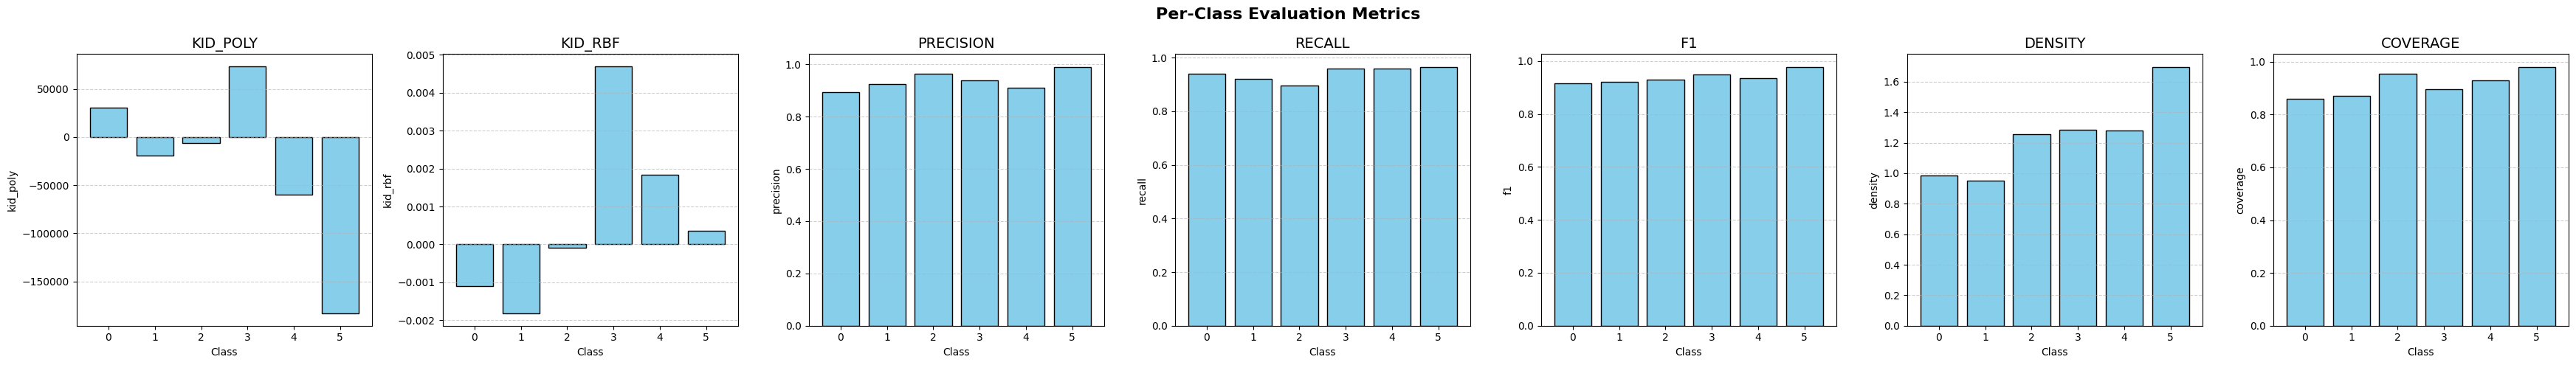

In [13]:
real_list_flow, real_list_flow_t = compute_features(
    real_list_flow, real_list_flow_t, classifier
)

visualize_tsne_per_class(real_list_flow, real_list_flow_t)

metrics_per_class_flow = evaluate_features(real_list_flow, real_list_flow_t)

plot_metrics_per_class(metrics_per_class_flow)

# x1_features_flow, real_features_flow = compute_features(
#     x1_list_flow, real_list_flow, encoder
# )

# visualize_tsne_per_class(x1_features_flow, real_features_flow)

# metrics_per_class_flow = evaluate_features(x1_features_flow, real_features_flow)

# plot_metrics_per_class(metrics_per_class_flow)

In [10]:
num_timesteps = 30
samples_per_class = 200
guidance_scale = 2.0

flow_generator = ScoreGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_score, real_list_score = compute_samples(
    generator=flow_generator,
    p_data=val_sampleable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

# visualize_samples_per_class(x1_list_score, real_list_score)

100%|██████████| 29/29 [00:09<00:00,  3.19it/s]


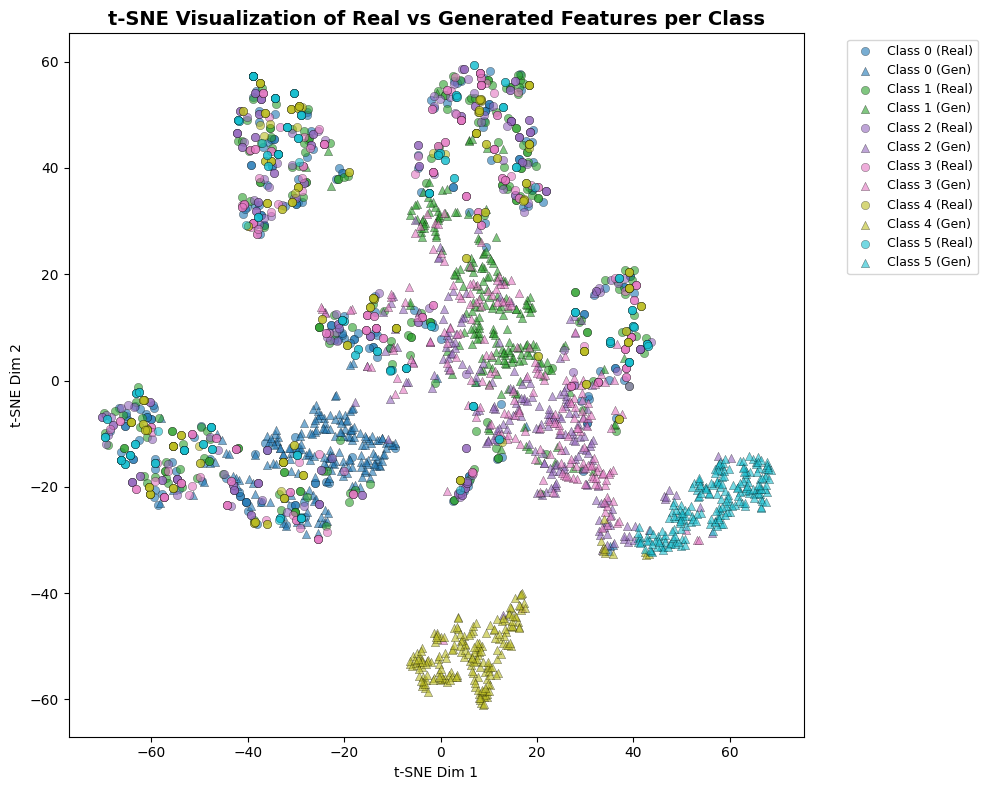

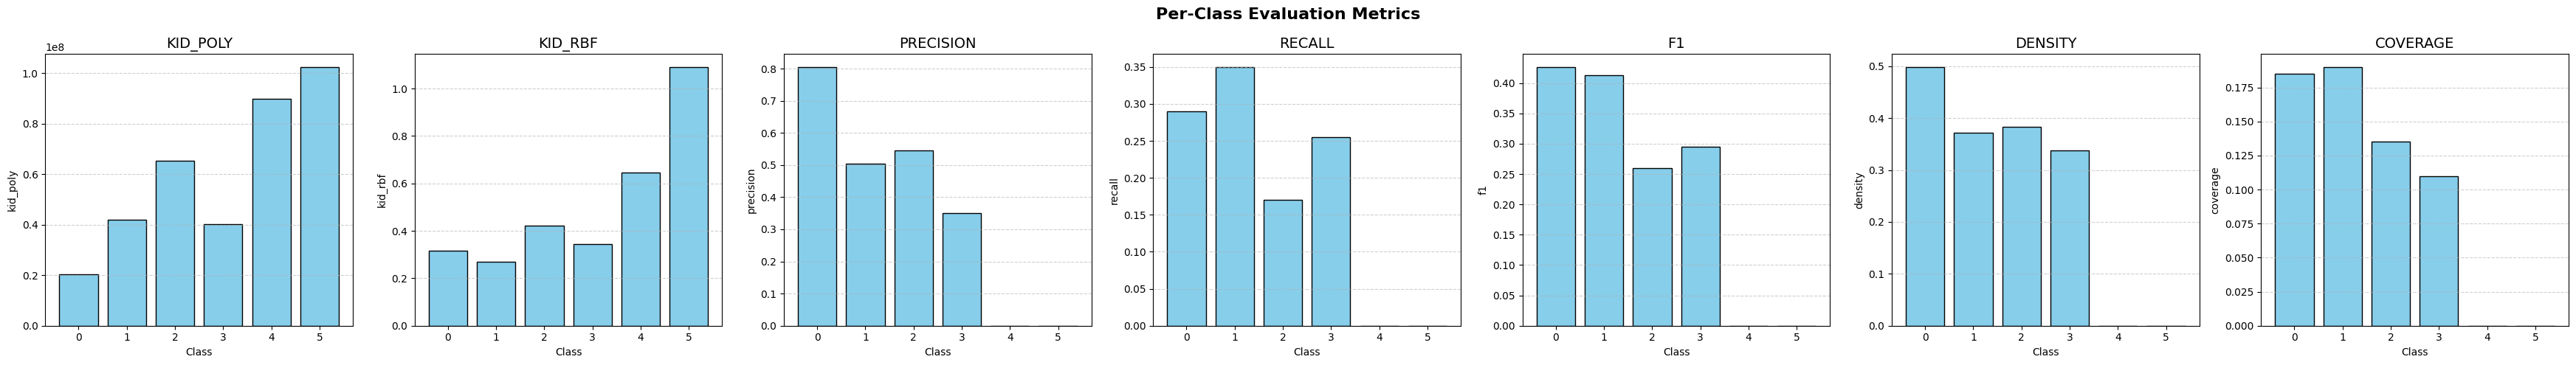

In [11]:
x1_features_score, real_features_score = compute_features(
    x1_list_score, real_list_score, encoder
)

visualize_tsne_per_class(x1_features_score, real_features_score)

metrics_per_class_score = evaluate_features(x1_features_score, real_features_score)

plot_metrics_per_class(metrics_per_class_score)

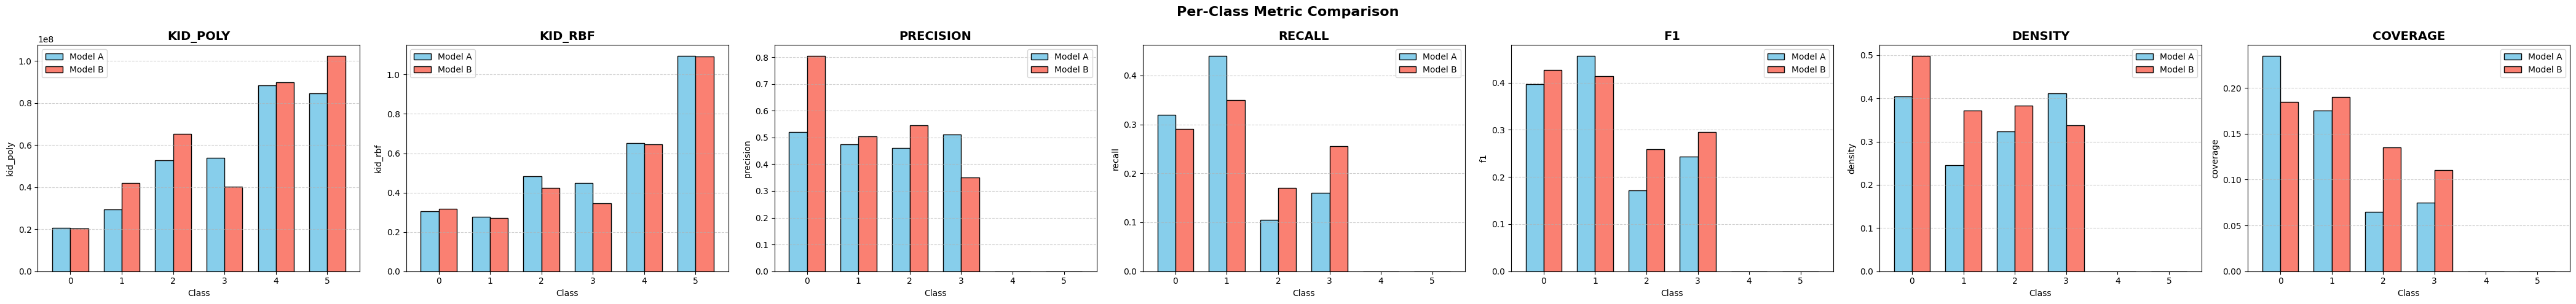

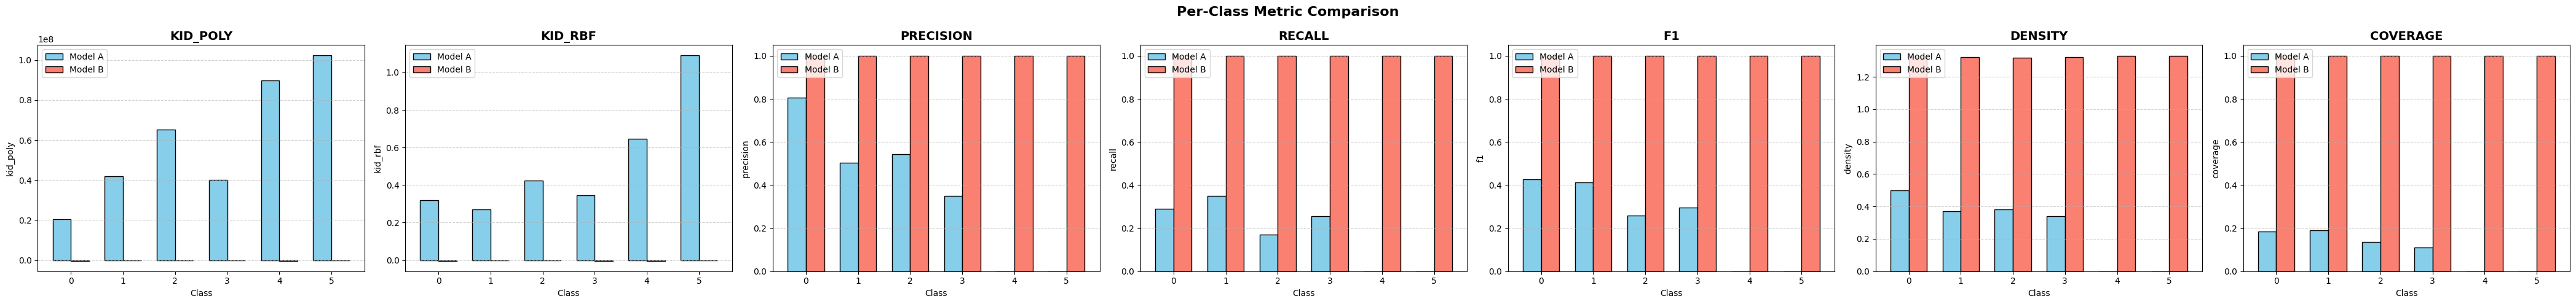

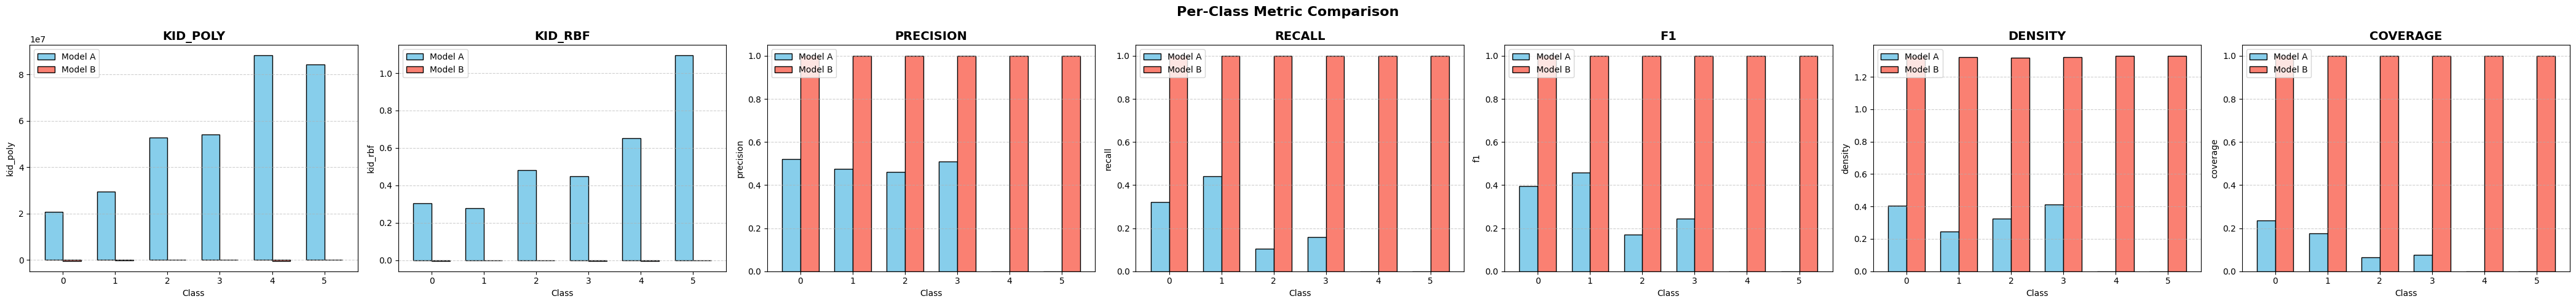

In [12]:
from diffusion.evaluation.evaluate import compare_metrics_per_class

metrics_per_class_perfect = evaluate_features(x1_features_score, x1_features_score)

compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_score)
compare_metrics_per_class(metrics_per_class_score, metrics_per_class_perfect)
compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_perfect)